In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 110
np.random.seed(42)

FILES = {
    "CO":  "Data_Polutan_Sekelas/ekstraksi_fitur_co.csv",
    "NO2": "Data_Polutan_Sekelas/ekstraksi_fitur_no2.csv",
    "SO2": "Data_Polutan_Sekelas/ekstraksi_fitur_so2.csv",
}


In [2]:
raw = {}
for name, path in FILES.items():
    df = pd.read_csv(path)
    raw[name] = df
    print(f"--- {name} ---")
    print(f"  Jumlah baris (sampel/lokasi) : {df.shape[0]}")
    print(f"  Jumlah kolom fitur           : {df.shape[1] - 3}  (di luar id, nama, daerah)")
    print(f"  Total nilai NaN              : {df.isna().sum().sum()}")
    print()


--- CO ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0

--- NO2 ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0

--- SO2 ---
  Jumlah baris (sampel/lokasi) : 37
  Jumlah kolom fitur           : 68  (di luar id, nama, daerah)
  Total nilai NaN              : 0



In [3]:
def preprocess(df):
    feat_cols = [c for c in df.columns if c not in ["id", "nama", "daerah"]]
    X = df[feat_cols].copy()
    X = X.fillna(X.median(numeric_only=True))

    nunique = X.nunique()
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        X = X.drop(columns=const_cols)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X, X_scaled, const_cols

processed = {}
for name, df in raw.items():
    X, X_scaled, dropped = preprocess(df)
    processed[name] = {"X": X, "X_scaled": X_scaled, "dropped": dropped}
    print(f"{name}: {X.shape[1]} fitur dipakai (dari 68) setelah membuang {len(dropped)} fitur konstan -> {dropped}")


CO: 65 fitur dipakai (dari 68) setelah membuang 3 fitur konstan -> ['human_range_energy', 'spectral_roll_on', 'zero_cross']
NO2: 66 fitur dipakai (dari 68) setelah membuang 2 fitur konstan -> ['human_range_energy', 'spectral_roll_on']
SO2: 66 fitur dipakai (dari 68) setelah membuang 2 fitur konstan -> ['human_range_energy', 'spectral_roll_on']


In [4]:
def hopkins_statistic(X, sample_ratio=0.3, random_state=42):
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    m = max(2, int(sample_ratio * n))

    nbrs = NearestNeighbors(n_neighbors=2).fit(X)

    # (a) jarak titik ASLI data ke tetangga terdekatnya (bukan dirinya sendiri)
    idx = rng.choice(n, m, replace=False)
    u_dist = [nbrs.kneighbors(X[i].reshape(1, -1), n_neighbors=2)[0][0][1] for i in idx]

    # (b) jarak titik ACAK (uniform, dalam bounding box data) ke titik data terdekat
    mins, maxs = X.min(axis=0), X.max(axis=0)
    rand_pts = rng.uniform(mins, maxs, size=(m, X.shape[1]))
    w_dist = [nbrs.kneighbors(p.reshape(1, -1), n_neighbors=1)[0][0][0] for p in rand_pts]

    U, W = np.sum(u_dist), np.sum(w_dist)
    return W / (U + W)

for name, d in processed.items():
    h = hopkins_statistic(d["X_scaled"])
    processed[name]["hopkins"] = h
    if h > 0.75:
        ket = "kecenderungan cluster KUAT"
    elif h > 0.6:
        ket = "kecenderungan cluster CUKUP"
    else:
        ket = "kecenderungan cluster LEMAH / mendekati acak"
    print(f"{name}: Hopkins Statistic = {h:.3f}  -> {ket}")


CO: Hopkins Statistic = 0.880  -> kecenderungan cluster KUAT
NO2: Hopkins Statistic = 0.842  -> kecenderungan cluster KUAT


SO2: Hopkins Statistic = 0.886  -> kecenderungan cluster KUAT


In [5]:
def evaluate_k_range(X, k_min=2, k_max=8):
    n = X.shape[0]
    k_max = min(k_max, n - 1)
    rows = []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(X)
        rows.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, labels),
        })
    res = pd.DataFrame(rows)
    best = res.loc[res["silhouette"].idxmax()]
    return res, int(best["k"]), float(best["silhouette"])


def plot_elbow_silhouette(res, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(res["k"], res["inertia"], marker="o", color="tab:blue")
    axes[0].set_title(f"Elbow Method — {title}")
    axes[0].set_xlabel("Jumlah cluster (k)")
    axes[0].set_ylabel("Inertia (WCSS)")
    axes[0].grid(alpha=0.3)

    axes[1].plot(res["k"], res["silhouette"], marker="o", color="tab:green")
    best_k = res.loc[res["silhouette"].idxmax(), "k"]
    axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"k terbaik = {best_k}")
    axes[1].set_title(f"Silhouette Score — {title}")
    axes[1].set_xlabel("Jumlah cluster (k)")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


In [6]:
N_TARGET = 37

for name, d in processed.items():
    n_samples, n_features = d["X_scaled"].shape
    n_actual = min(N_TARGET, n_samples, n_features)

    pca = PCA(n_components=n_actual, random_state=42)
    X_pca = pca.fit_transform(d["X_scaled"])
    cum_var = np.sum(pca.explained_variance_ratio_)

    d["pca_model"] = pca
    d["X_pca"] = X_pca
    d["n_comp_actual"] = n_actual
    d["cum_var"] = cum_var

    flag = "" if n_actual == N_TARGET else f"  (DIBATASI dari target {N_TARGET} karena hanya ada {n_samples} sampel)"
    print(f"{name}: {n_actual} komponen PCA -> variansi kumulatif dijelaskan = {cum_var*100:.2f}%{flag}")


CO: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%
NO2: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%
SO2: 37 komponen PCA -> variansi kumulatif dijelaskan = 100.00%


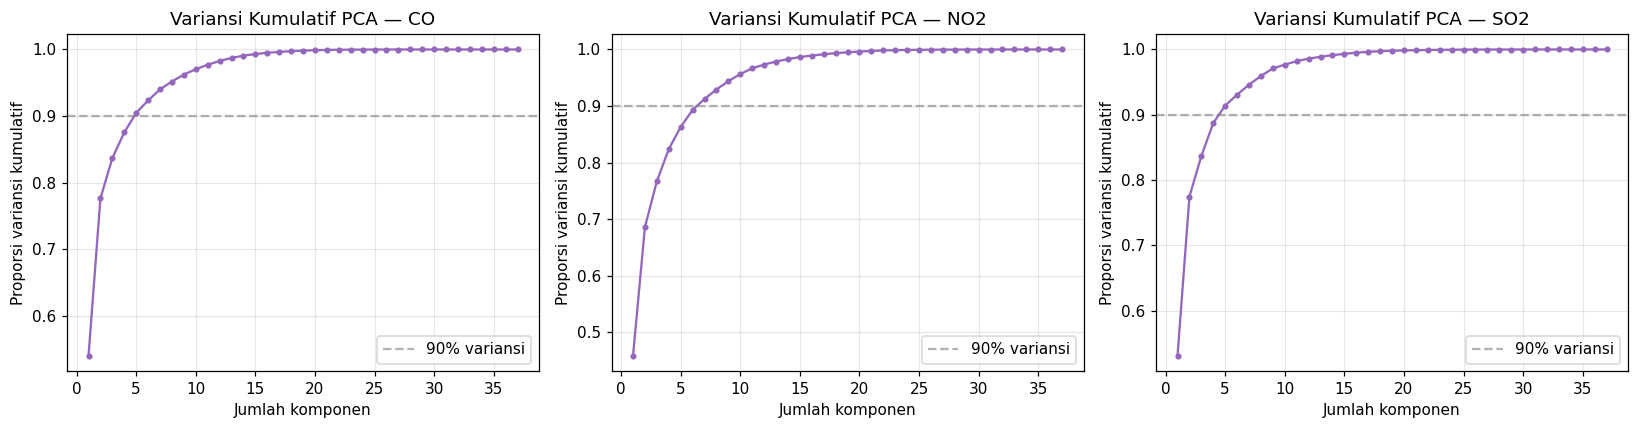

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, d) in zip(axes, processed.items()):
    cum = np.cumsum(d["pca_model"].explained_variance_ratio_)
    ax.plot(range(1, len(cum) + 1), cum, marker=".", color="tab:purple")
    ax.axhline(0.9, color="gray", linestyle="--", alpha=0.6, label="90% variansi")
    ax.set_title(f"Variansi Kumulatif PCA — {name}")
    ax.set_xlabel("Jumlah komponen")
    ax.set_ylabel("Proporsi variansi kumulatif")
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


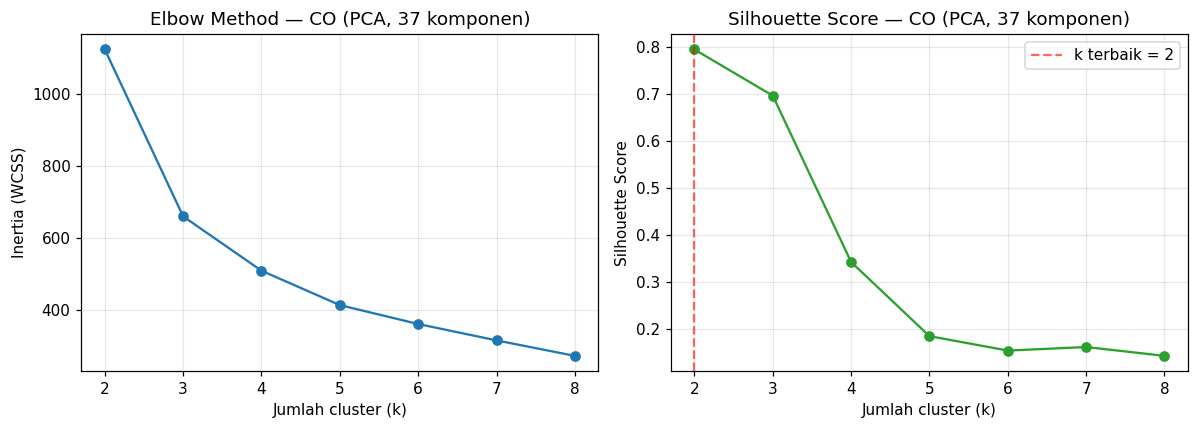

CO: k terbaik = 2  (silhouette = 0.795)



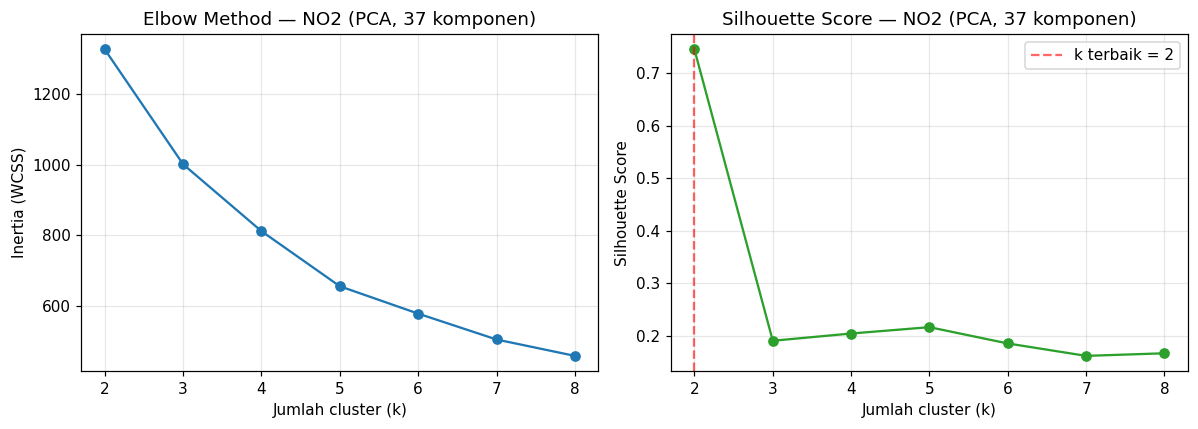

NO2: k terbaik = 2  (silhouette = 0.745)



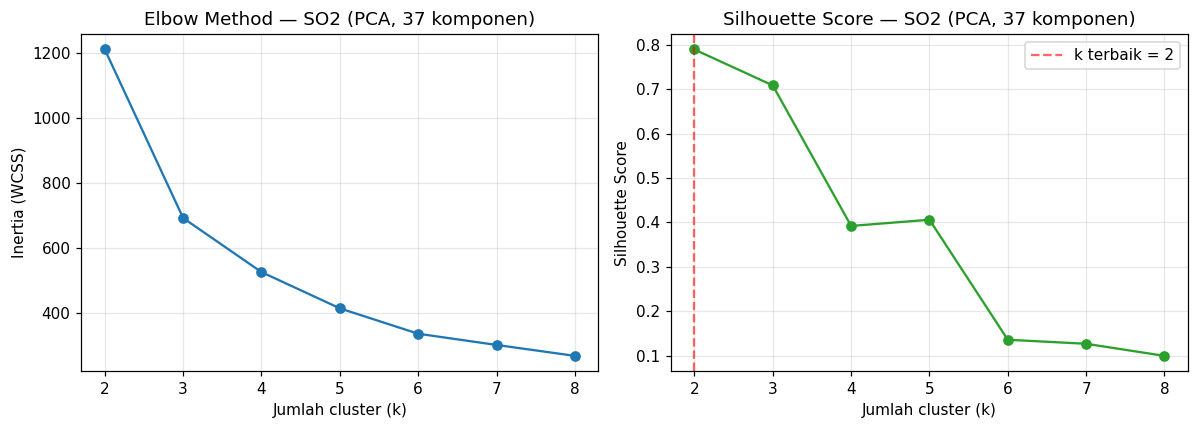

SO2: k terbaik = 2  (silhouette = 0.789)



In [8]:
pca_results = {}
for name, d in processed.items():
    res, k_best, sil_best = evaluate_k_range(d["X_pca"])
    pca_results[name] = (res, k_best, sil_best)
    plot_elbow_silhouette(res, f"{name} (PCA, {d['n_comp_actual']} komponen)")
    print(f"{name}: k terbaik = {k_best}  (silhouette = {sil_best:.3f})\n")


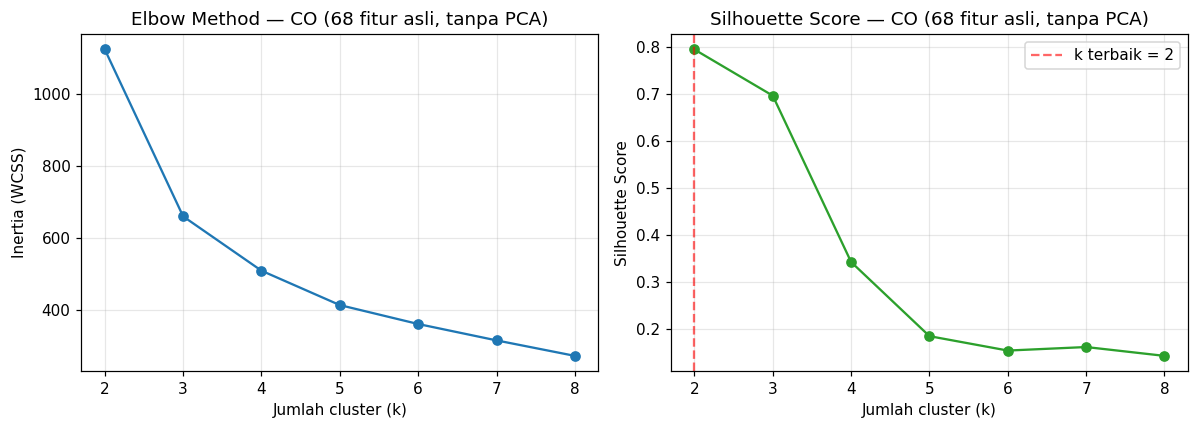

CO: k terbaik = 2  (silhouette = 0.795)



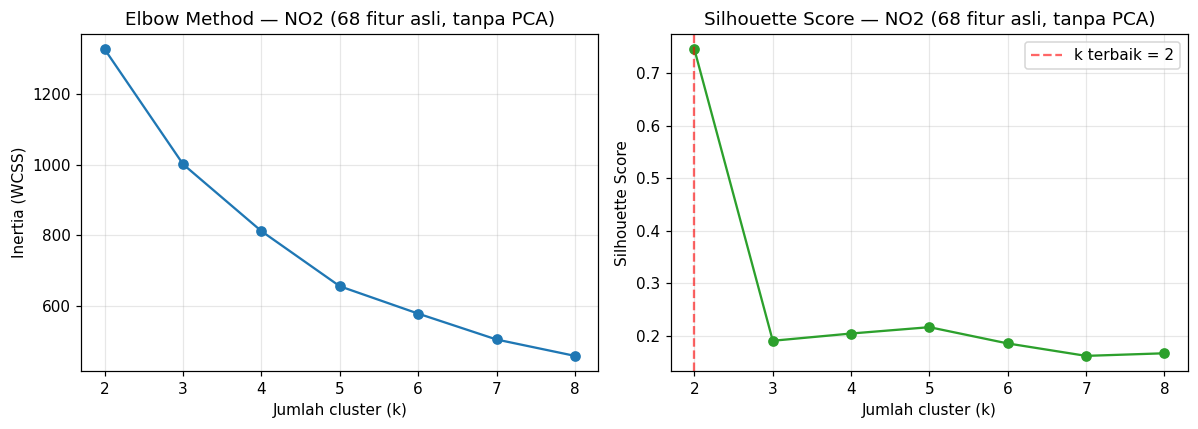

NO2: k terbaik = 2  (silhouette = 0.745)



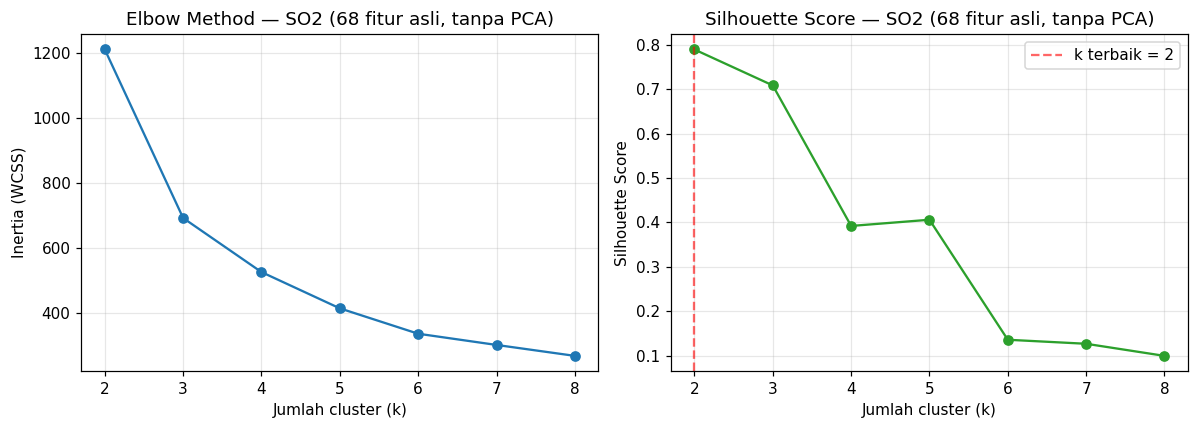

SO2: k terbaik = 2  (silhouette = 0.789)



In [9]:
full_results = {}
for name, d in processed.items():
    res, k_best, sil_best = evaluate_k_range(d["X_scaled"])
    full_results[name] = (res, k_best, sil_best)
    plot_elbow_silhouette(res, f"{name} (68 fitur asli, tanpa PCA)")
    print(f"{name}: k terbaik = {k_best}  (silhouette = {sil_best:.3f})\n")


In [10]:
summary_rows = []
for name, d in processed.items():
    _, k_pca, sil_pca = pca_results[name]
    _, k_full, sil_full = full_results[name]
    summary_rows.append({
        "Polutan": name,
        "n_sampel": d["X_scaled"].shape[0],
        "n_fitur_dipakai": d["X_scaled"].shape[1],
        "Hopkins": round(d["hopkins"], 3),
        "n_komponen_PCA": d["n_comp_actual"],
        "Var._dijelaskan_PCA (%)": round(d["cum_var"] * 100, 1),
        "k_terbaik (PCA)": k_pca,
        "Silhouette (PCA)": round(sil_pca, 3),
        "k_terbaik (68 fitur)": k_full,
        "Silhouette (68 fitur)": round(sil_full, 3),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Polutan,n_sampel,n_fitur_dipakai,Hopkins,n_komponen_PCA,Var._dijelaskan_PCA (%),k_terbaik (PCA),Silhouette (PCA),k_terbaik (68 fitur),Silhouette (68 fitur)
0,CO,37,65,0.880,37,100.0,2,0.795,2,0.795
1,NO2,37,66,0.842,37,100.0,2,0.745,2,0.745
2,SO2,37,66,0.886,37,100.0,2,0.789,2,0.789
